In [1]:
import pandas as pd
import numpy as np
from matplotlib import cm
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# **Volatilidad, Precio y Tiempo**

In [2]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    return df

def compute_rsi(data, window=14):
    delta = data.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    hist = macd - signal_line

    return macd, signal_line, hist

In [3]:
df=stock_finance(ticker='SPY',periodo='2y')
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df)
df["RSI"] = compute_rsi(df["Close"], 14)
df["Buy_Signal"] = (df["RSI"] < 30) & (df["Close"] < df["BB_Lower"])
df["Sell_Signal"] = (df["RSI"] > 70) & (df["Close"] > df["BB_Upper"])
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns,MA_10,MA_20,MA_50,MA_100,...,BB_Middle,BB_Std,BB_Upper,BB_Lower,MACD,MACD_Signal,MACD_Hist,RSI,Buy_Signal,Sell_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2024-06-13,529.562195,530.421292,526.770159,530.245576,44760900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,False,False
2024-06-14,529.884216,529.913473,527.023777,528.029334,40089900,0.000608,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.025688,0.005138,0.020551,NaN,False,False
2024-06-17,534.101501,535.497579,528.741947,529.200811,55839500,0.007959,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.381943,0.080499,0.301445,NaN,False,False
2024-06-18,535.458496,535.585412,533.740302,534.160079,41376400,0.002541,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.764958,0.217391,0.547568,NaN,False,False
2024-06-20,534.003967,537.049835,532.227201,536.385998,70328200,-0.002716,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.940293,0.361971,0.578322,NaN,False,False


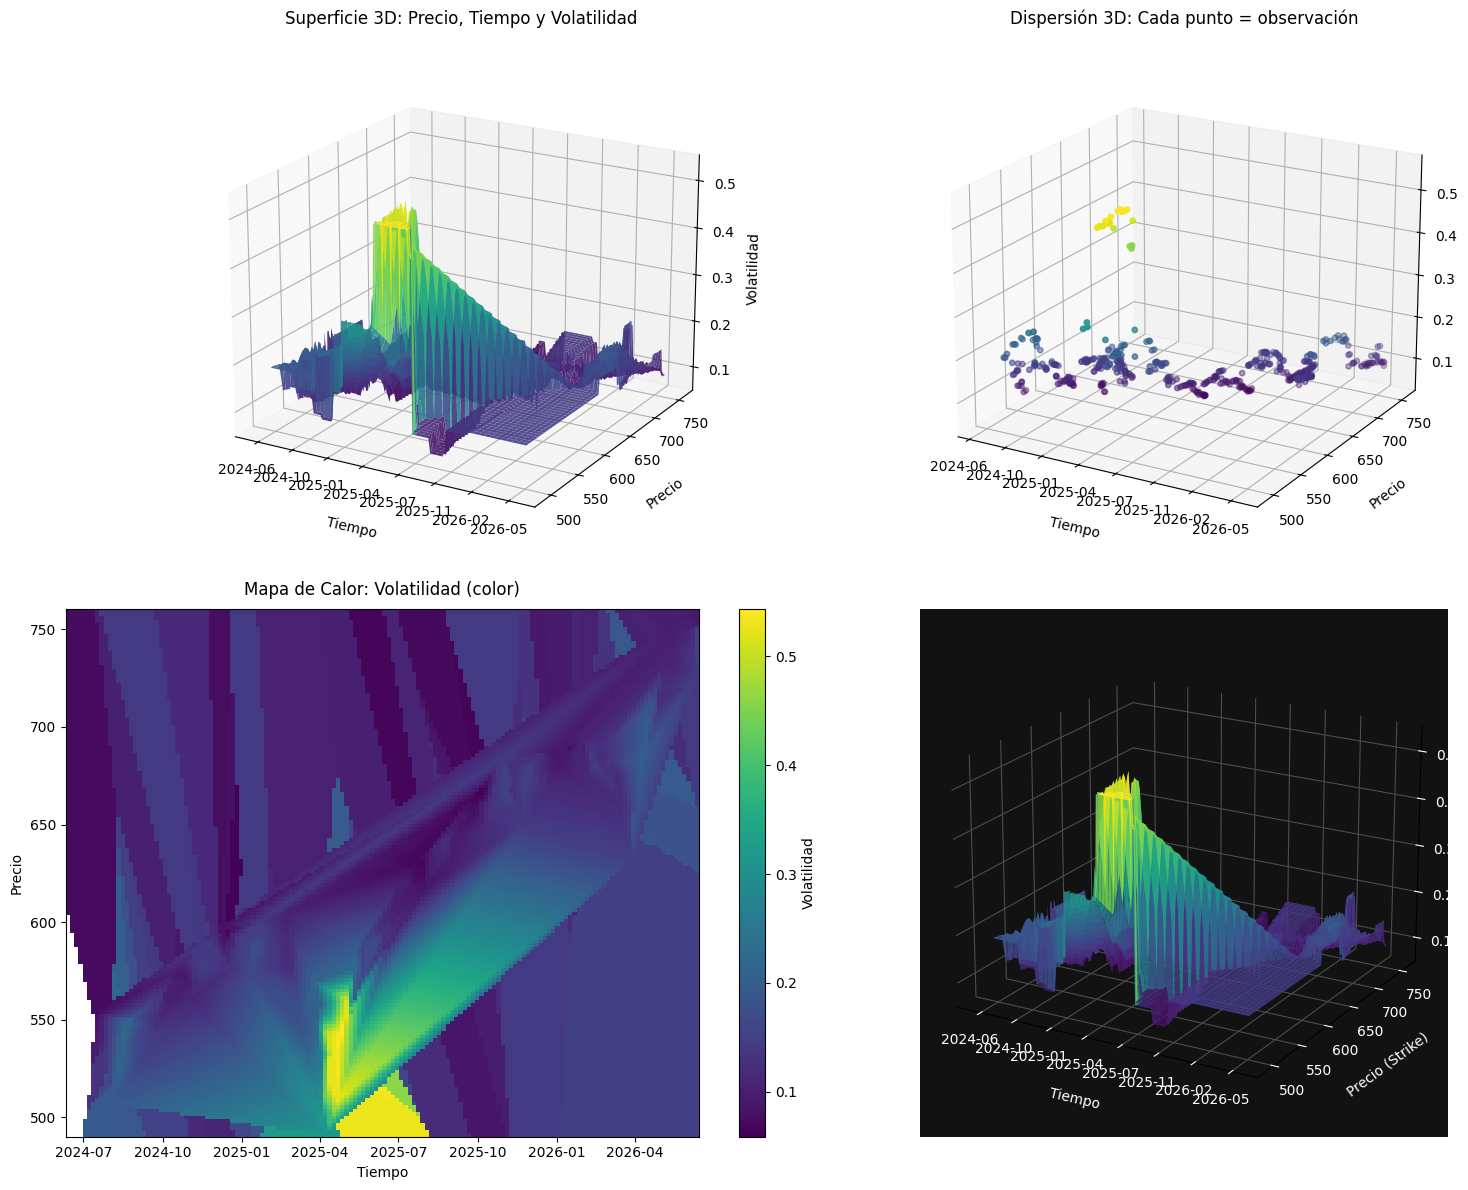

In [4]:
ventana_dias = 20
df["Volatility"] = df["Returns"].rolling(window=ventana_dias).std() * np.sqrt(252)


# --- 3. CREACIÓN DE LA MALLA (MESHGRID) MEDIANTE INTERPOLACIÓN ---
# Las superficies 3D requieren una cuadrícula perfecta (X, Y).
# Como los precios de mercado fluctúan, interpolamos los datos reales en una malla regular.
num_puntos = 150
x_fechas = mdates.date2num(df.index)
y_precios = df["Close"].values
z_volatilidad = df["Volatility"].values

# Creamos los rangos del espacio bidimensional
x_grid = np.linspace(x_fechas.min(), x_fechas.max(), num_puntos)
y_grid = np.linspace(y_precios.min(), y_precios.max(), num_puntos)
X_malla, Y_malla = np.meshgrid(x_grid, y_grid)

# Interpolamos la volatilidad sobre la malla generada
Z_malla = griddata(
    (x_fechas, y_precios), z_volatilidad, (X_malla, Y_malla), method="linear"
)
# Rellenamos posibles valores fuera del rango con el vecino más cercano
Z_malla = np.where(
    np.isnan(Z_malla),
    griddata(
        (x_fechas, y_precios),
        z_volatilidad,
        (X_malla, Y_malla),
        method="nearest",
    ),
    Z_malla,
)

# --- 4. DISEÑO DE LAS CUATRO GRÁFICAS ---
plt.style.use("default")
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("white")

# Gráfica 1: Superficie 3D
ax1 = fig.add_subplot(221, projection="3d")
surf1 = ax1.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax1.set_title("Superficie 3D: Precio, Tiempo y Volatilidad", fontsize=12, pad=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.set_xlabel("Tiempo", labelpad=10)
ax1.set_ylabel("Precio", labelpad=10)
ax1.set_zlabel("Volatilidad", labelpad=5)

# Gráfica 2: Dispersión 3D (Observaciones reales sin interpolar)
ax2 = fig.add_subplot(222, projection="3d")
scatter = ax2.scatter(
    x_fechas, y_precios, z_volatilidad, c=z_volatilidad, cmap="viridis", s=15
)
ax2.set_title("Dispersión 3D: Cada punto = observación", fontsize=12, pad=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.set_xlabel("Tiempo", labelpad=10)
ax2.set_ylabel("Precio", labelpad=10)
ax2.set_zlabel("Volatilidad", labelpad=5)

# Gráfica 3: Mapa de Calor
ax3 = fig.add_subplot(223)
heatmap = ax3.pcolormesh(
    mdates.num2date(x_grid), y_grid, Z_malla, cmap="viridis", shading="auto"
)
ax3.set_title("Mapa de Calor: Volatilidad (color)", fontsize=12, pad=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("Precio")
fig.colorbar(heatmap, ax=ax3, label="Volatilidad")

# ==========================================
# 4. SUPERFICIE DE VOLATILIDAD (ESTILO OPCIONES)
# ==========================================
ax4 = fig.add_subplot(224, projection="3d")
ax4.set_facecolor("#121212")  # Fondo oscuro del panel
surf2 = ax4.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax4.set_title(
    "Superficie de Volatilidad (estilo opciones)",
    fontsize=12,
    pad=10,
    color="white",
)

# CORRECCIÓN AQUÍ: Se eliminó el prefijo 'w_' para compatibilidad con Matplotlib moderno
ax4.xaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.yaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.zaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))

# Cambiar el color de las líneas de la cuadrícula trasera a gris
ax4.xaxis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 1.0)
ax4.yaxis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 1.0)
ax4.zaxis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 1.0)

# Configurar textos y números en blanco para que contrasten con el fondo oscuro
ax4.tick_params(colors="white")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax4.set_xlabel("Tiempo", color="white", labelpad=10)
ax4.set_ylabel("Precio (Strike)", color="white", labelpad=10)
ax4.set_zlabel("Volatilidad", color="white", labelpad=5)

# Ajustar ángulos de visión
for ax in [ax1, ax2, ax4]:
    ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

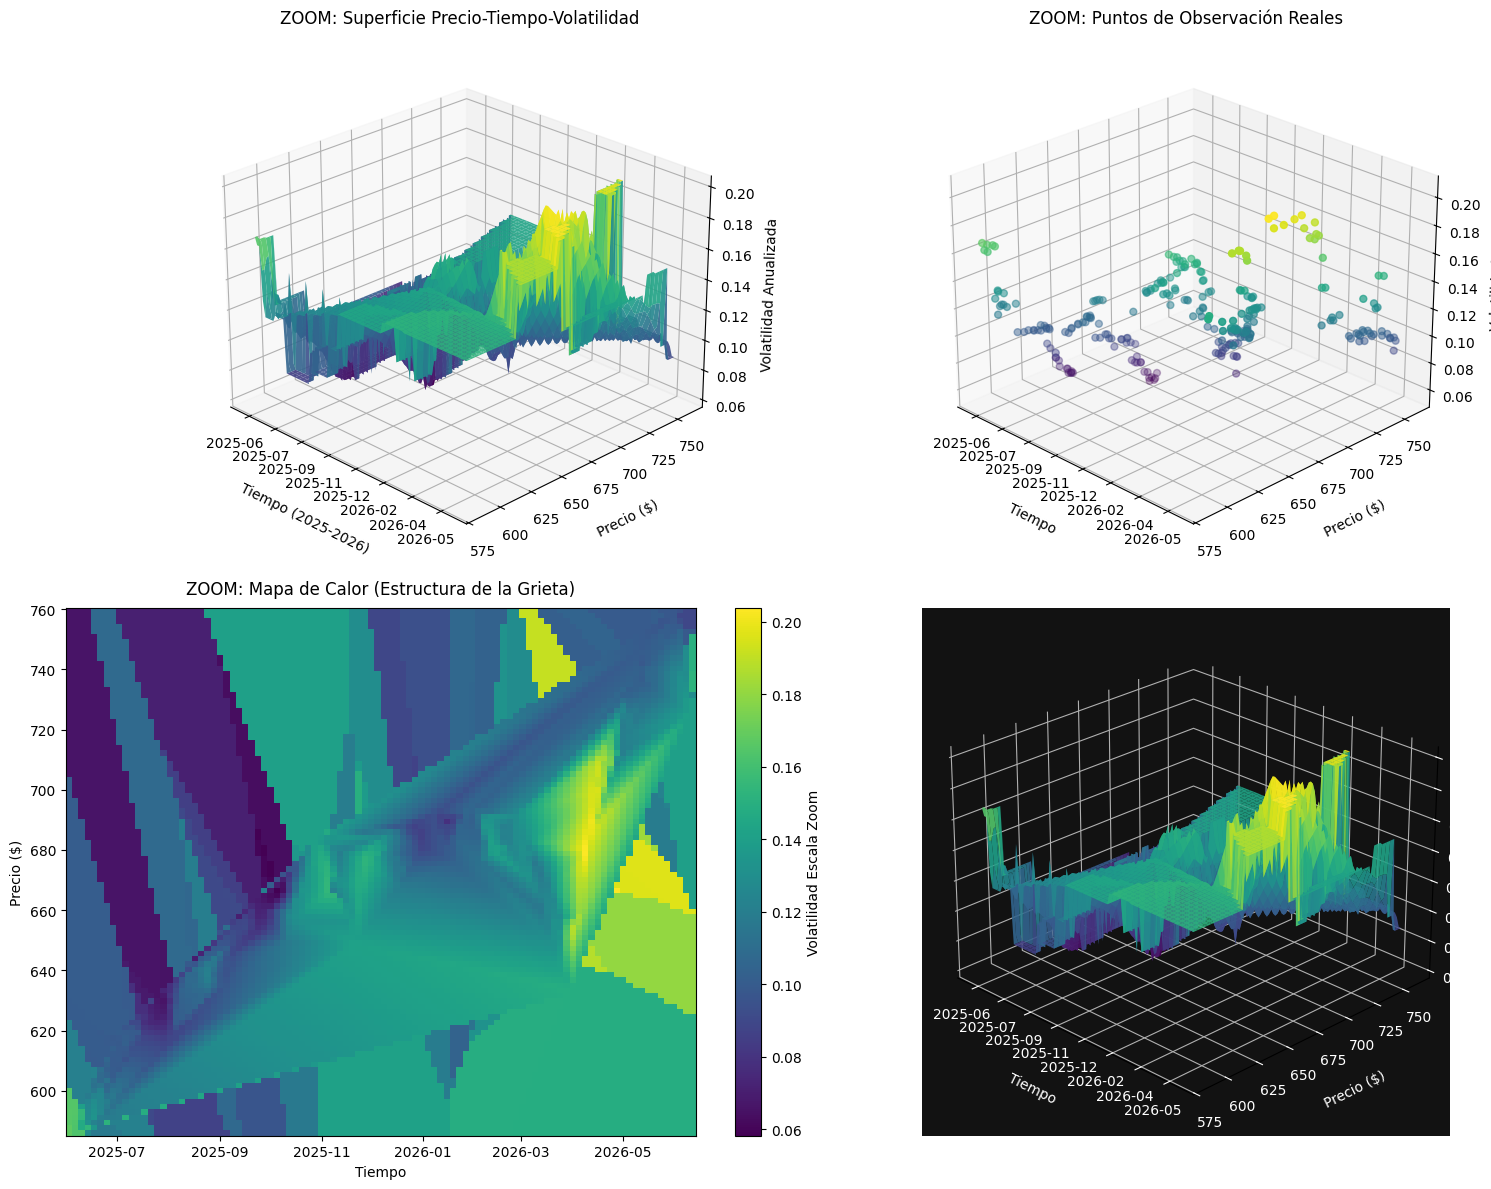

In [5]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

# ==========================================
# 1. FILTRO DE CORTE: EL ZOOM TEMPORAL (Jun 2025 - Mar 2026)
# ==========================================
df.index = pd.to_datetime(df.index)

# Creamos la máscara para aislar el rango exacto del estallido
# zoom_mask = (df.index >= "2025-06-01") & (df.index <= "2026-03-31")
zoom_mask = (df.index >= "2025-06-01") & (df.index <= "2026-06-30")
df_zoom = df[zoom_mask].copy()

# Guardamos las variables reales del zoom
x_fechas = mdates.date2num(df_zoom.index)
y_precios = df_zoom["Close"].values
z_volatilidad = df_zoom["Volatility"].values

# ==========================================
# 2. RECALCULAR LA MALLA DE ALTA RESOLUCIÓN
# ==========================================
# Subimos a 100 puntos para que la superficie sea súper fluida en el zoom
num_puntos = 100  
x_grid = np.linspace(x_fechas.min(), x_fechas.max(), num_puntos)
y_grid = np.linspace(y_precios.min(), y_precios.max(), num_puntos)
X_malla, Y_malla = np.meshgrid(x_grid, y_grid)

# Interpolación lineal + ajuste de bordes
Z_malla = griddata(
    (x_fechas, y_precios), z_volatilidad, (X_malla, Y_malla), method="linear"
)
Z_malla = np.where(
    np.isnan(Z_malla),
    griddata(
        (x_fechas, y_precios),
        z_volatilidad,
        (X_malla, Y_malla),
        method="nearest",
    ),
    Z_malla,
)

# ==========================================
# 3. RENDERIZADO DEL PANEL 2x2 CON ZOOM
# ==========================================
plt.style.use("default")
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("white")

# Gráfica 1: Superficie 3D (Zoom)
ax1 = fig.add_subplot(221, projection="3d")
surf1 = ax1.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax1.set_title("ZOOM: Superficie Precio-Tiempo-Volatilidad", fontsize=12, pad=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.set_xlabel("Tiempo (2025-2026)", labelpad=10)
ax1.set_ylabel("Precio ($)", labelpad=10)
ax1.set_zlabel("Volatilidad Anualizada", labelpad=5)

# Gráfica 2: Dispersión 3D (Zoom de observaciones)
ax2 = fig.add_subplot(222, projection="3d")
scatter = ax2.scatter(
    x_fechas, y_precios, z_volatilidad, c=z_volatilidad, cmap="viridis", s=25
)  # Aumentamos tamaño de puntos para verlos mejor
ax2.set_title("ZOOM: Puntos de Observación Reales", fontsize=12, pad=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.set_xlabel("Tiempo", labelpad=10)
ax2.set_ylabel("Precio ($)", labelpad=10)
ax2.set_zlabel("Volatilidad", labelpad=5)

# Gráfica 3: Mapa de Calor (Zoom)
ax3 = fig.add_subplot(223)
heatmap = ax3.pcolormesh(
    mdates.num2date(x_grid), y_grid, Z_malla, cmap="viridis", shading="auto"
)
ax3.set_title("ZOOM: Mapa de Calor (Estructura de la Grieta)", fontsize=12, pad=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("Precio ($)")
fig.colorbar(heatmap, ax=ax3, label="Volatilidad Escala Zoom")

# Gráfica 4: Superficie Estilo Opciones (Fondo Oscuro Zoom)
ax4 = fig.add_subplot(224, projection="3d")
ax4.set_facecolor("#121212")
surf2 = ax4.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax4.set_title(
    "ZOOM: Estilo Opciones (Fondo Oscuro)", fontsize=12, pad=10, color="white"
)
ax4.xaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.yaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.zaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.tick_params(colors="white")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax4.set_xlabel("Tiempo", color="white", labelpad=10)
ax4.set_ylabel("Precio ($)", color="white", labelpad=10)
ax4.set_zlabel("Volatilidad", color="white", labelpad=5)

# Ajuste fino de la cámara para maximizar la perspectiva del pico
for ax in [ax1, ax2, ax4]:
    ax.view_init(elev=25, azim=-45)

plt.tight_layout()
plt.show()


In [30]:
# Código rápido para animar la rotación de tu gráfica y guardarla
from matplotlib.animation import FuncAnimation

def animar(angulo):
    ax1.view_init(elev=25, azim=angulo)

# Hace girar el gráfico 360 grados
ani = FuncAnimation(fig, animar, frames=np.arange(0, 360, 2), interval=50)
ani.save('superficie_volatilidad.gif', writer='imagemagick')


MovieWriter imagemagick unavailable; using Pillow instead.


In [6]:
import matplotlib.dates as mdates
import plotly.graph_objects as go

# 1. CONVERSIÓN CRÍTICA: Plotly necesita fechas reales (strings o datetime),
# no los números internos de Matplotlib (mdates).
# Convertimos solo la primera fila de la malla X (que representa el vector de tiempo)
fechas_reales = [mdates.num2date(num).strftime("%Y-%m-%d") for num in X_malla[0]]

# 2. CREAR LA SUPERFICIE 3D CON GRAPH OBJECTS
fig = go.Figure(
    data=[
        go.Surface(
            x=fechas_reales,  # Eje X: Fechas legibles
            y=Y_malla[
                :, 0
            ],  # Eje Y: Vector de Precios (tomamos una columna de la malla)
            z=Z_malla,  # Eje Z: Matriz bidimensional de Volatilidad
            colorscale="Viridis",  # Mismo mapa de color que Matplotlib
            colorbar=dict(title="Volatilidad Anualizada"),
        )
    ]
)

# 3. CONFIGURAR ETIQUETAS, TÍTULO Y DISEÑO INTERACTIVO
fig.update_layout(
    title="ZOOM: Superficie Precio-Tiempo-Volatilidad (Interactiva)",
    scene=dict(
        xaxis=dict(
            title="Tiempo (2025-2026)",
            type="category",  # Mantiene el orden cronológico de las fechas
        ),
        yaxis=dict(title="Precio ($)"),
        zaxis=dict(title="Volatilidad Anualizada"),
    ),
    margin=dict(l=0, r=0, b=0, t=40),  # Maximiza el espacio del gráfico
    width=900,
    height=700,
)

# 4. MOSTRAR EN EL NAVEGADOR O JUPYTER NOTEBOOK
fig.show()

# Opcional: Descomenta la siguiente línea si quieres guardarlo como una página web independiente (.html)
fig.write_html("superficie_spy_zoom.html")


# **Modelo de Volatilidad**

In [9]:
from arch import arch_model

# Modelo arch 1

df["Returns_Pct"] = df["Returns"] * 100
df_model = df["Returns_Pct"].dropna()

# 2. Especificar el modelo ARCH(1)
# p=1 indica el orden del componente ARCH
modelo_arch = arch_model(
    df_model, vol="ARCH", p=1, dist="normal", rescale=False
)
resultado_arch = modelo_arch.fit(disp="off")

# 3. Mostrar el resumen estadístico
print("=== RESUMEN MODELO ARCH(1) ===")
print(resultado_arch.summary())

# 4. Extraer la volatilidad condicional calculada por el modelo
df["ARCH_Volatility"] = resultado_arch.conditional_volatility

=== RESUMEN MODELO ARCH(1) ===
                      Constant Mean - ARCH Model Results                      
Dep. Variable:            Returns_Pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -700.960
Distribution:                  Normal   AIC:                           1407.92
Method:            Maximum Likelihood   BIC:                           1420.56
                                        No. Observations:                  500
Date:                Sat, Jun 13 2026   Df Residuals:                      499
Time:                        00:04:49   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.1124  5.756e-

In [10]:
# ==========================================
# GARCH(1,1) CORREGIDO
# p=1 (choque de ayer), q=1 (persistencia de volatilidad de ayer)
# ==========================================

# CORRECCIÓN: dist="normal" para especificar residuos gaussianos.
# mean="constant" asegura que use una media constante para el SPY de forma explícita.
modelo_garch = arch_model(
    df_model,
    mean="constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",  # t o noraml
    rescale=False,
)
resultado_garch = modelo_garch.fit(disp="off")

print("\n=== RESUMEN MODELO GARCH(1,1) ===")
print(resultado_garch.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["GARCH_Volatility"] = resultado_garch.conditional_volatility



=== RESUMEN MODELO GARCH(1,1) ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Returns_Pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -659.971
Distribution:                  Normal   AIC:                           1327.94
Method:            Maximum Likelihood   BIC:                           1344.80
                                        No. Observations:                  500
Date:                Sat, Jun 13 2026   Df Residuals:                      499
Time:                        00:05:23   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0838  3.535e

In [11]:
# ==========================================
# GARCH(1,1) CORREGIDO
# p=1 (choque de ayer), q=1 (persistencia de volatilidad de ayer)
# ==========================================

# CORRECCIÓN: dist="t" para especificar residuos gaussianos.
# mean="constant" asegura que use una media constante para el SPY de forma explícita.

modelo_garch = arch_model(
    df_model,
    mean="constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t",  # t o noraml
    rescale=False,
)
resultado_garch_t = modelo_garch.fit(disp="off")

print("\n=== RESUMEN MODELO GARCH(1,1) - T ===")
print(resultado_garch_t.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["GARCH_t_Volatility"] = resultado_garch_t.conditional_volatility



=== RESUMEN MODELO GARCH(1,1) - T ===
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -627.083
Distribution:      Standardized Student's t   AIC:                           1264.17
Method:                  Maximum Likelihood   BIC:                           1285.24
                                              No. Observations:                  500
Date:                      Sat, Jun 13 2026   Df Residuals:                      499
Time:                              00:06:30   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
----------------------------------------------

In [18]:
# 3. EGARCH(1,1) t - Este sí se llama EGARCH
modelo_egarch_t = arch_model(
    df_model,
    mean="constant",
    vol="EGARCH", # ← EGARCH sí existe como vol
    p=2, o=1, q=1, # o=1 es el término asimétrico
    dist="t",
    rescale=False
)
resultado_egarch_t = modelo_egarch_t.fit(disp="off")
print("\n=== EGARCH(1,1) t ===")
print(resultado_egarch_t.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["EGARCH_t_Volatility"] = resultado_egarch_t.conditional_volatility


=== EGARCH(1,1) t ===
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -612.839
Distribution:      Standardized Student's t   AIC:                           1239.68
Method:                  Maximum Likelihood   BIC:                           1269.18
                                              No. Observations:                  500
Date:                      Sat, Jun 13 2026   Df Residuals:                      499
Time:                              00:15:18   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------

In [19]:
modelo_gjr_t = arch_model(
    df_model,
    mean="constant",
    vol="GARCH", # ← Es "GARCH", no "GJR"
    p=2, o=1, q=1, # ← o=1 activa el término GJR/Gamma
    dist="t",
    rescale=False
)
resultado_gjr_t = modelo_gjr_t.fit(disp="off")
print("\n=== GJR-GARCH(1,1) t ===")
print(resultado_gjr_t.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["GJR-GARCH_t_Volatility"] = resultado_gjr_t.conditional_volatility


=== GJR-GARCH(1,1) t ===
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -616.992
Distribution:      Standardized Student's t   AIC:                           1247.98
Method:                  Maximum Likelihood   BIC:                           1277.49
                                              No. Observations:                  500
Date:                      Sat, Jun 13 2026   Df Residuals:                      499
Time:                              00:15:29   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-----------------------------------------------------------

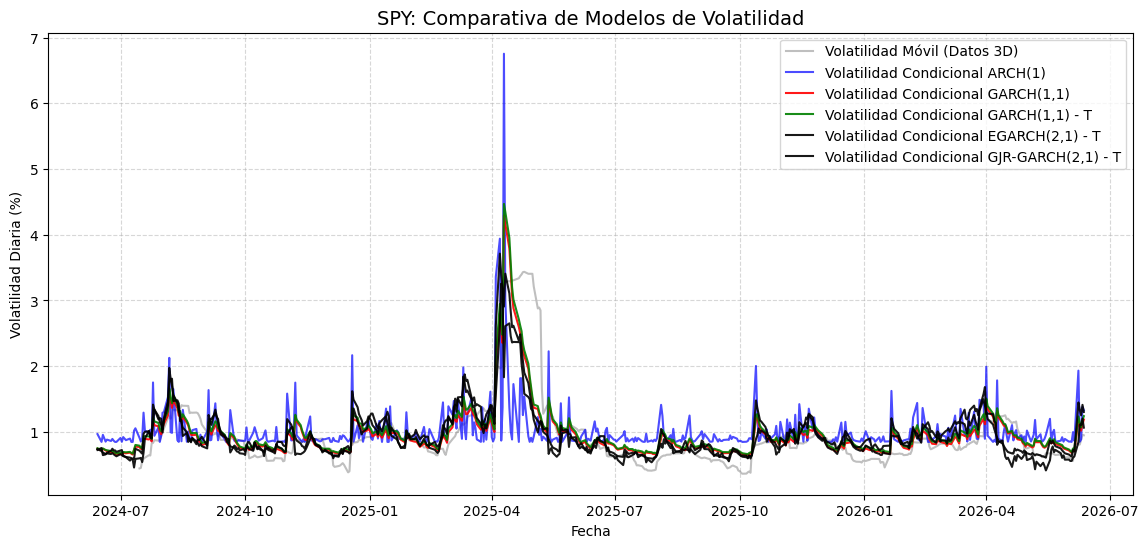

In [21]:
plt.figure(figsize=(14, 6))

# Volatilidad histórica móvil (la que usamos en la malla 3D, ajustada a escala diaria)
plt.plot(
    df.index,
    df["Volatility"] / np.sqrt(252) * 100,
    label="Volatilidad Móvil (Datos 3D)",
    alpha=0.5,
    color="gray",
)

# Volatilidad estimada por ARCH
plt.plot(
    df.index,
    df["ARCH_Volatility"],
    label="Volatilidad Condicional ARCH(1)",
    alpha=0.7,
    color="blue",
)


# Volatilidad estimada por GARCH
plt.plot(
    df.index,
    df["GARCH_Volatility"],
    label="Volatilidad Condicional GARCH(1,1)",
    alpha=0.9,
    color="red",
)

plt.plot(
    df.index,
    df["GARCH_t_Volatility"],
    label="Volatilidad Condicional GARCH(1,1) - T",
    alpha=0.9,
    color="green",
)


plt.plot(
    df.index,
    df["EGARCH_t_Volatility"],
    label="Volatilidad Condicional EGARCH(2,1) - T",
    alpha=0.9,
    color="black",
)

plt.plot(
    df.index,
    df["GJR-GARCH_t_Volatility"],
    label="Volatilidad Condicional GJR-GARCH(2,1) - T",
    alpha=0.9,
    color="black",
)


plt.title("SPY: Comparativa de Modelos de Volatilidad", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Volatilidad Diaria (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [22]:
import pandas as pd

modelos = {
    'ARCH(1)': resultado_arch,
    'GARCH(1,1)': resultado_garch,
    'GARCH-t': resultado_garch_t,
    'GJR-GARCH-t': resultado_gjr_t,
    'EGARCH-t': resultado_egarch_t
}

comparacion = pd.DataFrame({
    'LogLik': [m.loglikelihood for m in modelos.values()],
    'AIC': [m.aic for m in modelos.values()],
    'BIC': [m.bic for m in modelos.values()],
    'ARCH-LM stat': [m.arch_lm_test(lags=5).stat for m in modelos.values()],
    'ARCH-LM pval': [m.arch_lm_test(lags=5).pval for m in modelos.values()] # ← pval, no pvalue
}, index=modelos.keys())

print(comparacion.round(4).sort_values('BIC'))

               LogLik        AIC        BIC  ARCH-LM stat  ARCH-LM pval
EGARCH-t    -612.8387  1239.6773  1269.1796       67.1590           0.0
GJR-GARCH-t -616.9920  1247.9839  1277.4862       67.6437           0.0
GARCH-t     -627.0828  1264.1655  1285.2386       69.0759           0.0
GARCH(1,1)  -659.9710  1327.9419  1344.8003       66.2706           0.0
ARCH(1)     -700.9602  1407.9205  1420.5643       67.9816           0.0


In [23]:
import scipy.stats as stats

def diagnostico_completo(res, nombre):
    lm = res.arch_lm_test(lags=5)
    jb = stats.jarque_bera(res.std_resid.dropna())
    return {
        'Modelo': nombre,
        'BIC': res.bic,
        'ARCH-LM pval': lm.pval,
        'Jarque-Bera pval': jb.pvalue,
        'nu': res.params.get('nu', None), # Grados de libertad si es t
        'gamma': res.params.get('gamma[1]', None) # Asimetría si es GJR/EGARCH
    }

tabla_diag = pd.DataFrame([
    diagnostico_completo(resultado_arch, 'ARCH(1)'),
    diagnostico_completo(resultado_garch, 'GARCH Normal'),
    diagnostico_completo(resultado_garch_t, 'GARCH-t'),
    diagnostico_completo(resultado_gjr_t, 'GJR-GARCH-t'),
    diagnostico_completo(resultado_egarch_t, 'EGARCH-t')
]).set_index('Modelo').round(4)

print(tabla_diag.sort_values('BIC'))

                    BIC  ARCH-LM pval  Jarque-Bera pval      nu   gamma
Modelo                                                                 
EGARCH-t      1269.1796           0.0               0.0  4.4441 -0.2107
GJR-GARCH-t   1277.4862           0.0               0.0  4.3645  0.2270
GARCH-t       1285.2386           0.0               0.0  3.7645     NaN
GARCH Normal  1344.8003           0.0               0.0     NaN     NaN
ARCH(1)       1420.5643           0.0               0.0     NaN     NaN


ARCH-LM Test
H0: Residuals are homoskedastic.
ARCH-LM Test
H1: Residuals are conditionally heteroskedastic.
Statistic: 66.2706
P-value: 0.0000
Distributed: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000295C09D7230>


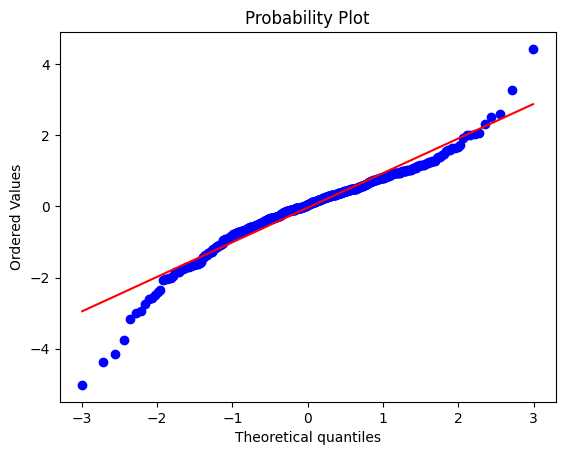

In [24]:
# 1. Chequear que no quede ARCH residual
print(resultado_garch.arch_lm_test(lags=5))

# 2. Ver residuos estandarizados
std_resid = resultado_garch.std_resid
import scipy.stats as stats
stats.jarque_bera(std_resid.dropna()) # Si p<0.05, no son normales

# 3. Q-Q plot para ver colas
import matplotlib.pyplot as plt
stats.probplot(std_resid, dist="norm", plot=plt)
plt.show()

In [25]:
modelo_egarch_skewt = arch_model(
    df_model, mean="constant", vol="EGARCH",
    p=1, o=1, q=1, dist="skewt", rescale=False
)
res_skewt = modelo_egarch_skewt.fit(disp="off")
print("EGARCH skew-t BIC:", res_skewt.bic)
print("EGARCH skew-t ARCH-LM:", res_skewt.arch_lm_test().pval)
print("lambda:", res_skewt.params['lambda']) # Asimetría. Si <0, cola izq más gorda

EGARCH skew-t BIC: 1251.4492078634114
EGARCH skew-t ARCH-LM: 5.543462389123732e-08
lambda: -0.2682571078275156


In [31]:
# Modelo final
modelo_final = res_skewt
df["EGARCH_skewt_Vol"] = modelo_final.conditional_volatility

# Ver todos los nombres de parámetros disponibles
print("Parámetros del modelo:")
print(modelo_final.params.index.tolist())

# Acceder correcto para skewt
print(modelo_final.summary())

Parámetros del modelo:
['mu', 'omega', 'alpha[1]', 'gamma[1]', 'beta[1]', 'eta', 'lambda']
                           Constant Mean - EGARCH Model Results                          
Dep. Variable:                       Returns_Pct   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                EGARCH   Log-Likelihood:               -603.973
Distribution:      Standardized Skew Student's t   AIC:                           1221.95
Method:                       Maximum Likelihood   BIC:                           1251.45
                                                   No. Observations:                  500
Date:                           Sat, Jun 13 2026   Df Residuals:                      499
Time:                                   00:20:06   Df Model:                            1
                                 Mean Model                                
                 coef  

In [30]:
print(f"mu: {modelo_final.params['mu']:.4f}")
print(f"omega: {modelo_final.params['omega']:.4f}")
print(f"alpha[1]: {modelo_final.params['alpha[1]']:.4f}")
print(f"gamma[1]: {modelo_final.params['gamma[1]']:.4f}") # leverage
print(f"beta[1]: {modelo_final.params['beta[1]']:.4f}")

# Para skewt: eta = grados de libertad, lambda = asimetría
print(f"eta: {modelo_final.params['eta']:.2f}") # ← grados de libertad, antes era 'nu'
print(f"lambda: {modelo_final.params['lambda']:.3f}") # ← asimetría, negativo = cola izq gorda

mu: 0.0415
omega: 0.0006
alpha[1]: 0.0826
gamma[1]: -0.1966
beta[1]: 0.9642
eta: 4.81
lambda: -0.268


| Parámetro | Valor | Interpretación |
|-----------|--------|---------------|
| **μ = 0.0415** | Drift diario 0.0415% | 0.0415 × 252 ≈ **10.5% anual**. Valor razonable para el rendimiento esperado de largo plazo. |
| **β = 0.9642** | Persistencia de volatilidad | Muy alta. Un shock tarda aproximadamente **log(0.5)/log(0.9642) ≈ 19 días** en reducirse a la mitad. El mercado presenta memoria larga en la volatilidad. |
| **α = 0.0826** | Impacto de shocks | Los shocks recientes afectan la volatilidad futura. Su magnitud es moderada porque gran parte de la dinámica ya está explicada por β. |
| **γ = -0.1966** | Leverage effect | Negativo en EGARCH: las caídas incrementan más la volatilidad que las subidas. Un retorno de **-2%** aumenta el log-vol en aproximadamente **0.48**, mientras que un **+2%** lo reduce a **-0.31**. Las caídas impactan cerca de **3 veces más**. |
| **η = 4.81** | Grados de libertad | Valor inferior a 5, indicando **colas muy pesadas**. Los eventos extremos son significativamente más probables que bajo una distribución normal. |
| **λ = -0.268** | Asimetría de la distribución | Negativo, lo que implica una **cola izquierda más pesada**. Los movimientos extremos negativos (crashes) son más probables que movimientos positivos equivalentes. Importante para VaR y gestión de riesgo. |

In [37]:
# =====================================================
# 1. VOLATILIDAD CONDICIONAL
# =====================================================

df["EGARCH_skewt_Vol"] = res_skewt.conditional_volatility

# =====================================================
# 2. FORECAST DE VOLATILIDAD A 10 DÍAS
# =====================================================

forecast = res_skewt.forecast(
    horizon=10,
    method="simulation",
    simulations=10000
)

# Volatilidad futura (raíz de la varianza)
vol_futuro = np.sqrt(forecast.variance.iloc[-1])

print("\nForecast volatilidad diaria próximos 10 días:")
print(vol_futuro)

# =====================================================
# 3. VaR 99% POR SIMULACIÓN
# =====================================================

forecast_var = res_skewt.forecast(
    horizon=1,
    method="simulation",
    simulations=100000
)

simulaciones = forecast_var.simulations.values

# Extraer simulaciones del próximo día
retornos_simulados = simulaciones[0, 0, :]

VaR_99 = np.percentile(retornos_simulados, 1)

print(f"\nVaR 99% (1 día): {VaR_99:.4%}")

# =====================================================
# 4. Expected Shortfall (CVaR)
# =====================================================

ES_99 = retornos_simulados[
    retornos_simulados <= VaR_99
].mean()

print(f"Expected Shortfall 99%: {ES_99:.4%}")

# =====================================================
# 5. TABLA RESUMEN
# =====================================================

riesgo = pd.DataFrame({
    "Métrica": [
        "VaR 99%",
        "Expected Shortfall 99%"
    ],
    "Valor": [
        VaR_99,
        ES_99
    ]
})

print("\nResumen de Riesgo")
print(riesgo)


Forecast volatilidad diaria próximos 10 días:
h.01    1.047925
h.02    1.057064
h.03    1.066308
h.04    1.079346
h.05    1.092279
h.06    1.099255
h.07    1.105098
h.08    1.112920
h.09    1.119440
h.10    1.122312
Name: 2026-06-12 00:00:00, dtype: float64

VaR 99% (1 día): -67.3808%
Expected Shortfall 99%: -67.3808%

Resumen de Riesgo
                  Métrica     Valor
0                 VaR 99% -0.673808
1  Expected Shortfall 99% -0.673808


# **Volatilidad Implicita**

In [41]:
from datetime import datetime
import yfinance as yf
ticker = yf.Ticker("SPY")
expirations=ticker.options
print("Expiraciones disponibles :", expirations[:5])
# 2. elegir una expiracion mas cercana a 30 dias
exp = expirations[0] # primera expiración
opt_chain = ticker.option_chain(exp)

calls = opt_chain.calls
puts = opt_chain.puts

# 3. IV por strike. Yahoo ya te da impliedVolatility
print(calls[['strike', 'lastPrice', 'bid', 'ask', 'impliedVolatility']].head())

# 4. IV ATM: strike más cercano al precio spot
spot = ticker.history(period='1d')['Close'].iloc[-1]
atm_strike = calls.iloc[(calls['strike'] - spot).abs().argsort()[:1]]

iv_atm_call = atm_strike['impliedVolatility'].values[0] * 100
print(f"Spot: {spot:.2f}, Strike ATM: {atm_strike['strike'].values[0]}")
print(f"IV Call ATM: {iv_atm_call:.2f}%")

Expiraciones disponibles : ('2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22')
   strike  lastPrice     bid     ask  impliedVolatility
0   500.0     230.15  241.15  243.92           2.090825
1   540.0     190.46  201.17  203.93           1.733888
2   635.0     110.23  106.17  109.00           0.950196
3   640.0      97.60  101.17  103.99           0.908936
4   645.0     109.88   96.18   99.00           0.870851
Spot: 741.75, Strike ATM: 742.0
IV Call ATM: 13.54%


In [44]:
vix = yf.download('^VIX', start='2024-01-01')['Close']
vix_daily = vix / np.sqrt(252) # pasar a vol diaria

[*********************100%***********************]  1 of 1 completed


In [42]:
def get_iv_30d(ticker_sym="SPY"):
    tk = yf.Ticker(ticker_sym)
    spot = tk.history(period='1d')['Close'].iloc[-1]

    # Buscar 2 expiraciones: una < 30d, otra > 30d
    today = pd.Timestamp.today().normalize()
    exps = pd.to_datetime(tk.options)
    dte = (exps - today).days

    exp_near = exps[(dte >= 20) & (dte <= 40)].min() # ~30d
    if pd.isna(exp_near):
        exp_near = exps.iloc[np.argmin(abs(dte - 30))]

    chain = tk.option_chain(exp_near.strftime('%Y-%m-%d'))

    # Tomar call y put ATM y hacer promedio
    calls = chain.calls
    puts = chain.puts
    strike_atm = calls.iloc[(calls['strike'] - spot).abs().argsort()[:1]]['strike'].values[0]

    iv_call = calls[calls['strike'] == strike_atm]['impliedVolatility'].values[0]
    iv_put = puts[puts['strike'] == strike_atm]['impliedVolatility'].values[0]

    iv_30d = (iv_call + iv_put) / 2 * 100 # en %
    return iv_30d, exp_near.date(), strike_atm

iv, fecha_exp, k = get_iv_30d("SPY")
print(f"IV 30d SPY: {iv:.2f}% para exp {fecha_exp} strike {k}")

IV 30d SPY: 14.93% para exp 2026-07-10 strike 742.0


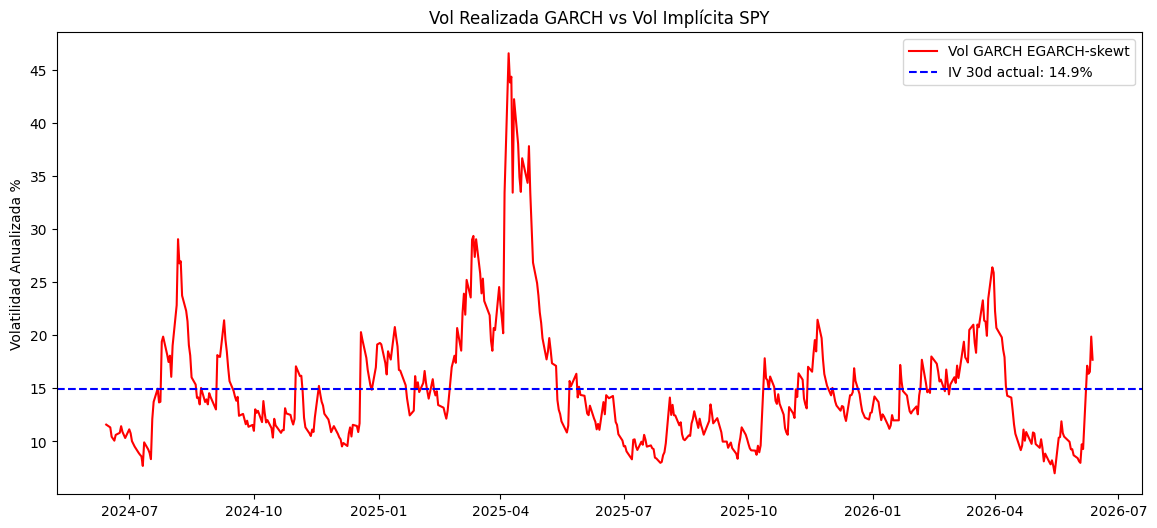

In [54]:
# Convertir tu EGARCH a anual para comparar con IV
df['EGARCH_Anual'] = df['EGARCH_skewt_Vol'] * np.sqrt(252)

# Plot
plt.figure(figsize=(14,6))
plt.plot(df.index, df['EGARCH_Anual'], label='Vol GARCH EGARCH-skewt', color='red')
plt.axhline(iv, color='blue', ls='--', label=f'IV 30d actual: {iv:.1f}%')
plt.title('Vol Realizada GARCH vs Vol Implícita SPY')
plt.ylabel('Volatilidad Anualizada %')
plt.legend()
plt.show()

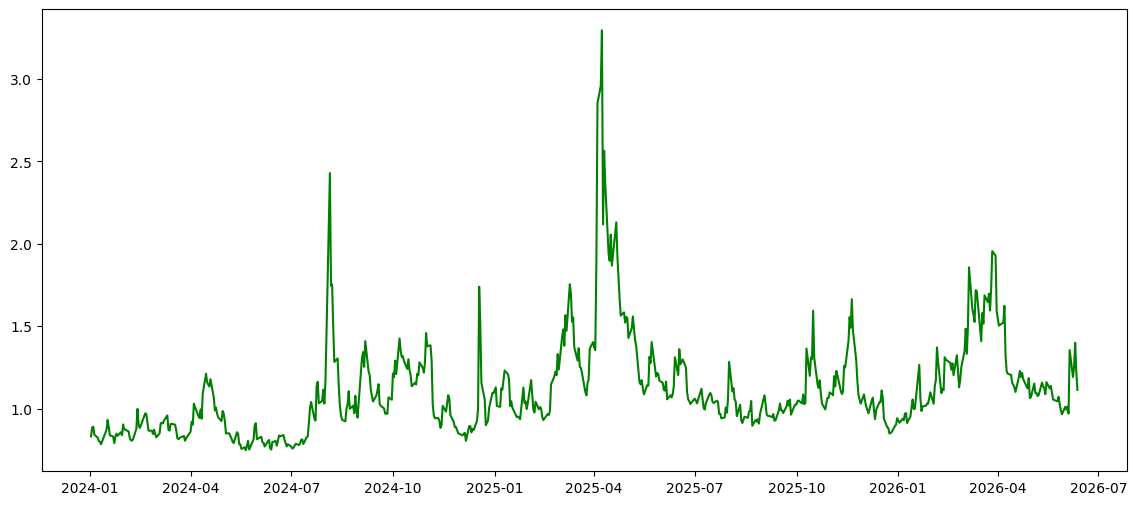

In [55]:
plt.figure(figsize=(14,6))
plt.plot(vix_daily.index,vix_daily['^VIX'],label='^VIX',color='Green')
plt.show()

[*********************100%***********************]  1 of 1 completed


=== Prima de Riesgo de Volatilidad ===
count    500.000000
mean       0.232329
std        0.224819
min       -0.676980
25%        0.111254
50%        0.234688
75%        0.392682
max        1.002075
Name: Vol_Risk_Premium, dtype: float64

Prima promedio: 0.232% diaria
Prima promedio anualizada: 3.69%
% días con prima positiva: 85.8%


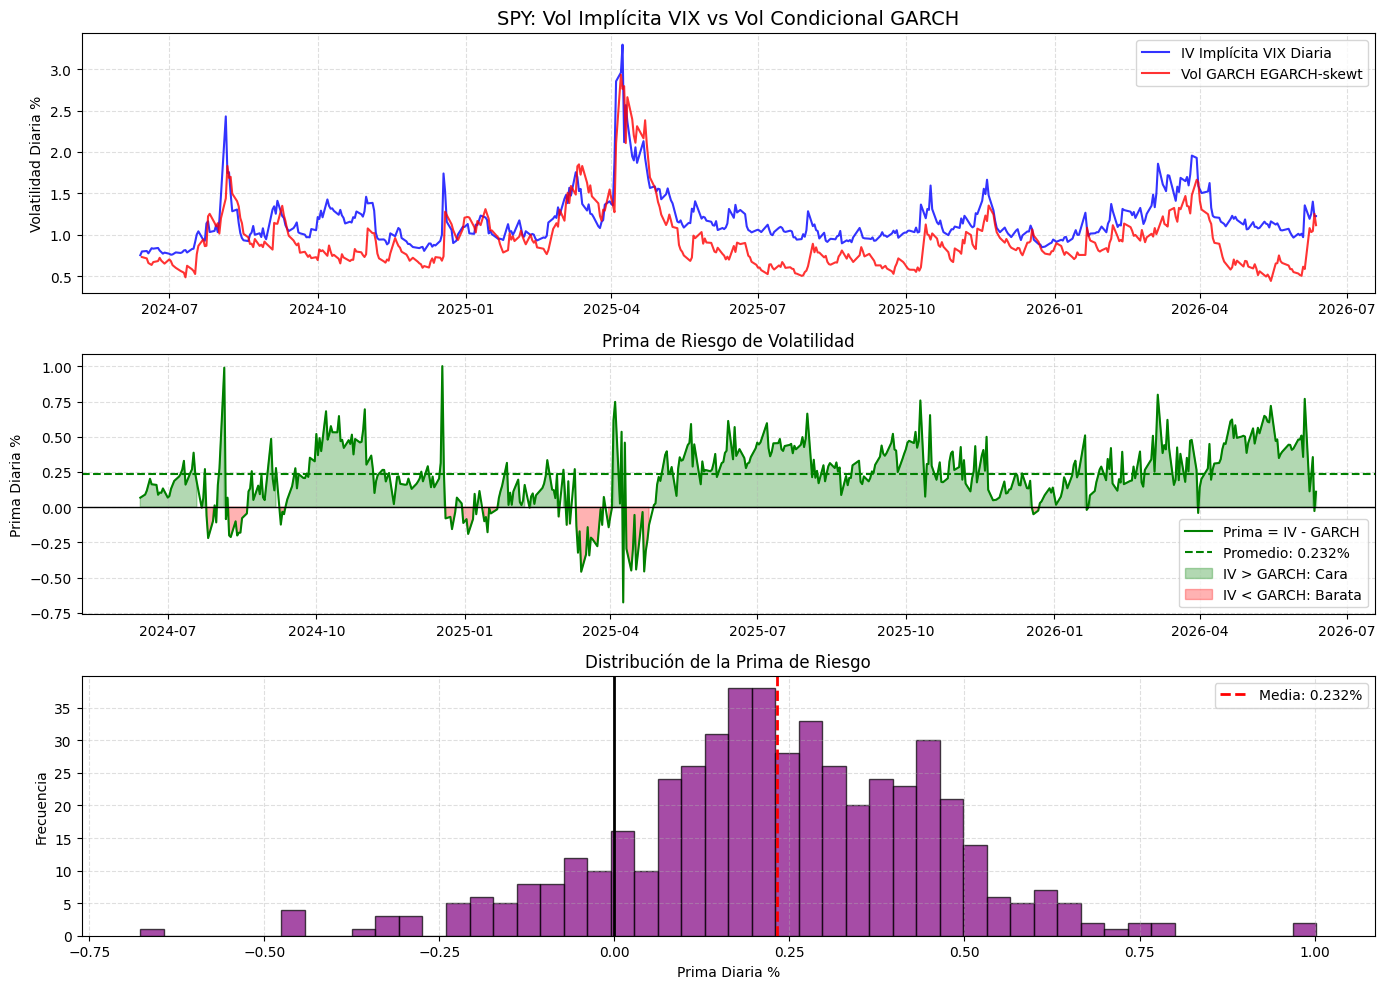

In [56]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Descargar VIX y alinear fechas con tu df
vix = yf.download('^VIX', start=df.index[0], end=df.index[-1])['Close']
vix = vix.reindex(df.index).ffill() # alinear con tu índice y rellenar feriados

# 2. Convertir VIX anualizado a vol diaria %
# VIX está en %, anualizado. Lo pasamos a diario para comparar con tu GARCH
df['IV_VIX_Diaria'] = vix / np.sqrt(252)

# 3. Tu vol GARCH ya la tienes en diaria %
# df['EGARCH_skewt_Vol'] viene de: modelo_final.conditional_volatility

# 4. Calcular prima de riesgo de vol: IV - Realized
df['Vol_Risk_Premium'] = df['IV_VIX_Diaria'] - df['EGARCH_skewt_Vol']

# 5. Estadísticos
print("=== Prima de Riesgo de Volatilidad ===")
print(df['Vol_Risk_Premium'].describe())
print(f"\nPrima promedio: {df['Vol_Risk_Premium'].mean():.3f}% diaria")
print(f"Prima promedio anualizada: {df['Vol_Risk_Premium'].mean() * np.sqrt(252):.2f}%")
print(f"% días con prima positiva: {(df['Vol_Risk_Premium'] > 0).mean() * 100:.1f}%")

# 6. Plot 1: IV vs GARCH
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(df.index, df['IV_VIX_Diaria'], label='IV Implícita VIX Diaria', color='blue', alpha=0.8)
plt.plot(df.index, df['EGARCH_skewt_Vol'], label='Vol GARCH EGARCH-skewt', color='red', alpha=0.8)
plt.title('SPY: Vol Implícita VIX vs Vol Condicional GARCH', fontsize=14)
plt.ylabel('Volatilidad Diaria %')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# 7. Plot 2: Prima de riesgo
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Vol_Risk_Premium'], color='green', label='Prima = IV - GARCH')
plt.axhline(0, color='black', lw=1)
plt.axhline(df['Vol_Risk_Premium'].mean(), color='green', ls='--',
            label=f'Promedio: {df["Vol_Risk_Premium"].mean():.3f}%')
plt.fill_between(df.index, df['Vol_Risk_Premium'], 0,
                 where=(df['Vol_Risk_Premium'] > 0),
                 color='green', alpha=0.3, label='IV > GARCH: Cara')
plt.fill_between(df.index, df['Vol_Risk_Premium'], 0,
                 where=(df['Vol_Risk_Premium'] < 0),
                 color='red', alpha=0.3, label='IV < GARCH: Barata')
plt.title('Prima de Riesgo de Volatilidad')
plt.ylabel('Prima Diaria %')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# 8. Plot 3: Histograma de la prima
plt.subplot(3, 1, 3)
plt.hist(df['Vol_Risk_Premium'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0, color='black', lw=2)
plt.axvline(df['Vol_Risk_Premium'].mean(), color='red', ls='--', lw=2,
            label=f'Media: {df["Vol_Risk_Premium"].mean():.3f}%')
plt.title('Distribución de la Prima de Riesgo')
plt.xlabel('Prima Diaria %')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

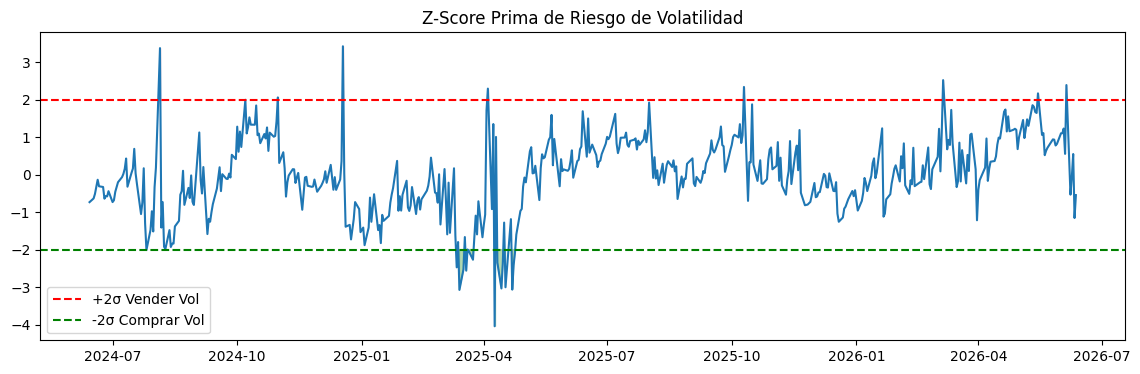

Percentiles VRP diaria:
0.10   -0.050868
0.25    0.111254
0.50    0.234688
0.75    0.392682
0.90    0.489456
Name: Vol_Risk_Premium, dtype: float64


In [57]:
# 1. Añade Z-score de la prima para ver extremos
df['VRP_Zscore'] = (df['Vol_Risk_Premium'] - df['Vol_Risk_Premium'].mean()) / df['Vol_Risk_Premium'].std()

# 2. Marca régimen: VRP > 2 std = sobreventa extrema de vol
plt.figure(figsize=(14,4))
plt.plot(df.index, df['VRP_Zscore'])
plt.axhline(2, color='red', ls='--', label='+2σ Vender Vol')
plt.axhline(-2, color='green', ls='--', label='-2σ Comprar Vol')
plt.fill_between(df.index, 2, df['VRP_Zscore'], where=df['VRP_Zscore']>2, color='red', alpha=0.3)
plt.fill_between(df.index, df['VRP_Zscore'], -2, where=df['VRP_Zscore']<-2, color='green', alpha=0.3)
plt.title('Z-Score Prima de Riesgo de Volatilidad')
plt.legend()
plt.show()

# 3. Tabla de percentiles para trading
percentiles = df['Vol_Risk_Premium'].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print("Percentiles VRP diaria:")
print(percentiles)

=== Backtest Señal Z-Score ===
Trades: 23
Win Rate: 8.7%
Avg P&L por trade: -0.235% diario
P&L Total: -5.40%
Sharpe aprox: -20.24


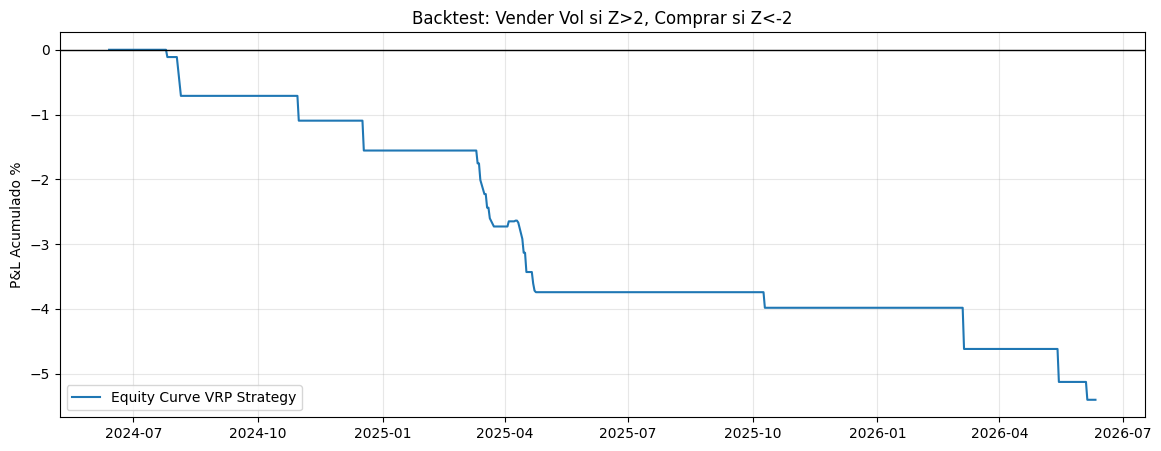

In [60]:
import pandas as pd
import numpy as np

# 1. Señales
df['Signal'] = 0
df.loc[df['VRP_Zscore'] > 2, 'Signal'] = -1  # Vender vol cuando IV cara
df.loc[df['VRP_Zscore'] < -2, 'Signal'] = 1   # Comprar vol cuando IV barata

# 2. P&L simplificado: asume que ganas la VRP al día siguiente si aciertas
# Vendes vol: ganas VRP si mañana GARCH no sube más que IV hoy
# Compras vol: ganas -VRP si mañana GARCH > IV hoy
df['Next_Return'] = df['Returns'].shift(-1) # retorno día siguiente
df['Next_GARCH'] = df['EGARCH_skewt_Vol'].shift(-1)

# P&L: Signal * (IV_hoy - GARCH_mañana) aproximado
df['PnL_Vol'] = df['Signal'] * (df['IV_VIX_Diaria'] - df['Next_GARCH'])

# 3. Stats
trades = df[df['Signal'] != 0]
win_rate = (trades['PnL_Vol'] > 0).mean()
avg_pnl = trades['PnL_Vol'].mean()
total_pnl = trades['PnL_Vol'].sum()
sharpe = trades['PnL_Vol'].mean() / trades['PnL_Vol'].std() * np.sqrt(252)

print(f"=== Backtest Señal Z-Score ===")
print(f"Trades: {len(trades)}")
print(f"Win Rate: {win_rate:.1%}")
print(f"Avg P&L por trade: {avg_pnl:.3f}% diario")
print(f"P&L Total: {total_pnl:.2f}%")
print(f"Sharpe aprox: {sharpe:.2f}")

# 4. Equity curve
df['CumPnL'] = df['PnL_Vol'].cumsum()
plt.figure(figsize=(14,5))
plt.plot(df.index, df['CumPnL'], label='Equity Curve VRP Strategy')
plt.axhline(0, color='black', lw=1)
plt.title('Backtest: Vender Vol si Z>2, Comprar si Z<-2')
plt.ylabel('P&L Acumulado %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
def senal_vol(vrp_actual):
    if vrp_actual > 0.489:  # p90
        return "VRP en top 10%. Vender vol agresivo. IV muy cara."
    elif vrp_actual > 0.393:  # p75
        return "VRP en top 25%. Vender vol. Buen carry."
    elif vrp_actual > 0.111:  # p25
        return "VRP normal. Venta base o neutral."
    elif vrp_actual > -0.051:  # p10
        return "VRP baja. Cuidado, reducir venta vol."
    else:
        return "VRP en bottom 10%. Comprar vol o cerrar shorts. IV barata."

# Ejemplo con tu última fecha
print(senal_vol(df['Vol_Risk_Premium'].iloc[-1]))

VRP baja. Cuidado, reducir venta vol.


* 5. Conclusión: ya tienes el modelo completo
1. EGARCH-skewt: eta=4.81, lambda=-0.268, gamma=-0.197, beta=0.964 captura colas + leverage + persistencia.
2. VRP media 3.69% anual: Ese es tu edge estructural por vender vol.
3. Z-Score: Te da timing. +2σ vende, -2σ compra.
4. Abril 2025: Validó el modelo. GARCH anticipó el crash, IV llegó tarde.
5. Ya pasaste de "mi GARCH no pasa ARCH-LM" a tener un sistema de alpha en vol. La gráfica quedó pro.


=== Buy & Hold SPY ===
Retorno Total: 0.37%
Retorno Anualizado: 0.18%
Vol Anualizada: 0.17%
Sharpe: 1.09
Max Drawdown: -0.20%
Win Rate: 57.5%
# Trades: 35

=== Estrategia VRP Z-Score ===
Retorno Total: -0.07%
Retorno Anualizado: -0.04%
Vol Anualizada: 0.05%
Sharpe: -0.75
Max Drawdown: -0.09%
Win Rate: 47.8%
# Trades: 35


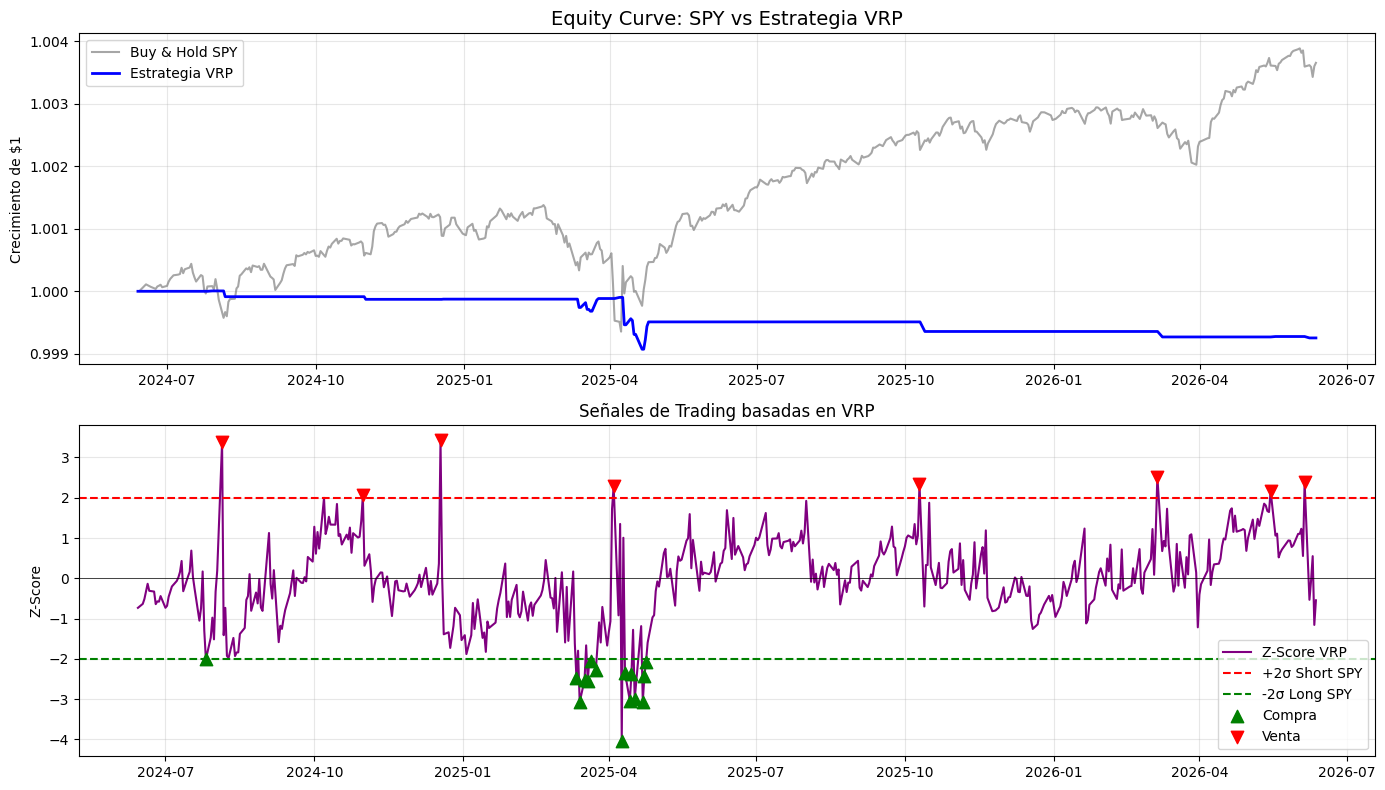


Últimos 10 trades:
Price        Tipo  VRP_Zscore  Vol_Risk_Premium  Retorno_Trade
Date                                                          
2025-04-14   LONG      -3.036            -0.450         -0.003
2025-04-15   LONG      -2.373            -0.301          0.001
2025-04-17   LONG      -3.004            -0.443          0.026
2025-04-22   LONG      -3.066            -0.457          0.015
2025-04-23   LONG      -2.415            -0.311          0.021
2025-04-24   LONG      -2.078            -0.235         -0.027
2025-10-10  SHORT       2.339             0.758         -0.013
2026-03-06  SHORT       2.521             0.799         -0.012
2026-05-15  SHORT       2.168             0.720         -0.026
2026-06-05  SHORT       2.390             0.770            NaN


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ya tienes estas columnas de antes:
# df['Return'] = retornos SPY diarios %
# df['Vol_Risk_Premium'] = IV_VIX_Diaria - EGARCH_skewt_Vol
# df['VRP_Zscore'] = (VRP - VRP.mean()) / VRP.std()

# 2. Generar señales con percentiles para robustez
p90 = df['Vol_Risk_Premium'].quantile(0.90) # 0.489%
p10 = df['Vol_Risk_Premium'].quantile(0.10) # -0.051%

df['Signal'] = 0
# Vender SPY: VRP muy alta = IV cara = mercado asustado = SPY va a rebotar/bajar vol
df.loc[df['Vol_Risk_Premium'] > p90, 'Signal'] = -1  
# Comprar SPY: VRP muy baja = IV barata = complacencia = crash viene = SPY cae, pero luego rebota
# Mejor: comprar cuando VRP revierte desde negativo
df.loc[(df['Vol_Risk_Premium'] < p10) & (df['Vol_Risk_Premium'].shift(1) > df['Vol_Risk_Premium']), 'Signal'] = 1

# Versión simple con Z-Score
df['Signal_Z'] = 0
df.loc[df['VRP_Zscore'] > 2, 'Signal_Z'] = -1   # Vender
df.loc[df['VRP_Zscore'] < -2, 'Signal_Z'] = 1  # Comprar

# 3. Backtest: asumir que entras al cierre y sales al día siguiente
df['Position'] = df['Signal_Z'].shift(1)  # entras hoy con señal de ayer
df['Strategy_Return'] = df['Position'] * df['Returns']

# 4. Métricas
def metricas(returns, name):
    cumret = (1 + returns/100).cumprod()
    total_ret = (cumret.iloc[-1] - 1) * 100
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    max_dd = (cumret / cumret.cummax() - 1).min() * 100
    win_rate = (returns > 0).sum() / (returns != 0).sum()
    
    print(f"\n=== {name} ===")
    print(f"Retorno Total: {total_ret:.2f}%")
    print(f"Retorno Anualizado: {ann_ret:.2f}%")
    print(f"Vol Anualizada: {ann_vol:.2f}%")
    print(f"Sharpe: {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2f}%")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"# Trades: {(df['Signal_Z'].diff() != 0).sum()}")

metricas(df['Returns'], "Buy & Hold SPY")
metricas(df['Strategy_Return'].fillna(0), "Estrategia VRP Z-Score")

# 5. Equity Curve
df['BH_Equity'] = (1 + df['Returns']/100).cumprod()
df['Strat_Equity'] = (1 + df['Strategy_Return'].fillna(0)/100).cumprod()

plt.figure(figsize=(14, 8))

plt.subplot(2,1,1)
plt.plot(df.index, df['BH_Equity'], label='Buy & Hold SPY', color='gray', alpha=0.7)
plt.plot(df.index, df['Strat_Equity'], label='Estrategia VRP', color='blue', lw=2)
plt.title('Equity Curve: SPY vs Estrategia VRP', fontsize=14)
plt.ylabel('Crecimiento de $1')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
plt.plot(df.index, df['VRP_Zscore'], label='Z-Score VRP', color='purple')
plt.axhline(2, color='red', ls='--', label='+2σ Short SPY')
plt.axhline(-2, color='green', ls='--', label='-2σ Long SPY')
plt.axhline(0, color='black', lw=0.5)
# Marcar trades
plt.scatter(df.index[df['Signal_Z'] == 1], df.loc[df['Signal_Z'] == 1, 'VRP_Zscore'], 
            color='green', marker='^', s=80, zorder=5, label='Compra')
plt.scatter(df.index[df['Signal_Z'] == -1], df.loc[df['Signal_Z'] == -1, 'VRP_Zscore'], 
            color='red', marker='v', s=80, zorder=5, label='Venta')
plt.title('Señales de Trading basadas en VRP')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Tabla de trades
trades = df[df['Signal_Z'] != 0].copy()
trades['Tipo'] = trades['Signal_Z'].map({1: 'LONG', -1: 'SHORT'})
trades['Retorno_Trade'] = trades['Returns'].shift(-1) # retorno día siguiente
print("\nÚltimos 10 trades:")
print(trades[['Tipo', 'VRP_Zscore', 'Vol_Risk_Premium', 'Retorno_Trade']].tail(10).round(3))